# Modeling Data in Kotlin

Different languages provide "kind of different" interpretation in it's built-in data structures. In Kotlin, we have `data class` and `enum class` to model our data in a more structured way. But we don't have such flexibility as in Swift which borrows concepts from functional programming and provides `struct`, `class`, `enum` and `protocol` to model data. In Kotlin, we can use `data class` to model simple data structures and `enum class` to model a fixed set of constants. In other hand, we can use `sealed class` to model a closed set of subclasses, which is similar to Swift's `enum` with associated values.

To get a better understanding of these concepts, let's take a look at a simple example of a "Messaging App".

![image.png](./Screenshot 2026-05-22 114543.png)

We have different types of messages in this simple app:

- Join messages
- Text messages
- Sticker messages (for simplicity only "send ballons" is accepted in this app)
- Leave messages
- Draft messages (someone is writing).

Let's create a model that can represent this messages:
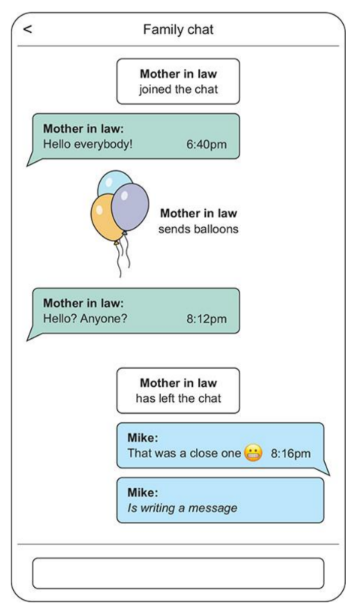

In [1]:
import java.util.Date

data class Message(
    val userId: Int,
    val date: Date = Date(),
    val hasJoined: Boolean = true, // Set the joined boolean at creation time
    val hasLeft: Boolean = false,
    val isBeingDraft: Boolean = false,
    val isSendingBalloons: Boolean = false,
    val text: String? = null
)

// Example usage
val joinMessage = Message(
    userId = 1,
    hasJoined = true,
)

val textMessage = Message(
    userId = 1,
    text = "Hello, everyone!"
)

val baloonsMessage = Message(
    userId = 2,
    isSendingBalloons = true,
)

println(textMessage.text ?: "No text provided")

Hello, everyone!


## Problems with this approach

Nothing prevents us from creating an invalid message, for example:

> [!WARNING]
> A message can be a Join and Leave message at the same time, plus have a message

In [2]:
val invalidMessage = Message(
    userId = 3,
    hasJoined = true,
    hasLeft = true, // This is an invalid message, because a user cannot join and leave at the same time
    text = "This message is invalid"
)

println(invalidMessage)

Message(userId=3, date=Fri May 22 12:03:27 GMT-04:00 2026, hasJoined=true, hasLeft=true, isBeingDraft=false, isSendingBalloons=false, text=This message is invalid)


## Data Classes that can Help Us

In kotlin we can use `enum class` to model a fixed set of constants, and `sealed class` to model a closed set of subclasses. Let's see how we can use these concepts to model our messages in a more structured way.

In [5]:
sealed class GoodMessage {
    class TextMessage(val userId: Int, val text: String) : GoodMessage()
    class StickerMessage(val userId: Int, val stickerId: String) : GoodMessage()
    class JoinMessage(val userId: Int) : GoodMessage()
    class LeaveMessage(val userId: Int) : GoodMessage()
    class DraftMessage(val userId: Int) : GoodMessage()
}

With this approach, we can only create valid messages, because each message type is represented by a different class. For example, we cannot create a message that is both a Join and Leave message at the same time, because they are different classes.

In [6]:
val validTextMessage = GoodMessage.TextMessage(
    userId = 1,
    text = "Hello, everyone!"
)

println(validTextMessage.text)

Hello, everyone!


## Leverage with when expression

With this approach, we can also leverage the power of `when` expression to handle different message types in a more structured way. For example, we can create a function that takes a `GoodMessage` and prints its content:

In [7]:
fun printMessage(message: GoodMessage) {
    when (message) {
        is GoodMessage.TextMessage -> println("Text message from user ${message.userId}: ${message.text}")
        is GoodMessage.StickerMessage -> println("Sticker message from user ${message.userId}: ${message.stickerId}")
        is GoodMessage.JoinMessage -> println("User ${message.userId} has joined the chat")
        is GoodMessage.LeaveMessage -> println("User ${message.userId} has left the chat")
        is GoodMessage.DraftMessage -> println("User ${message.userId} is typing...")
    }
}

printMessage(validTextMessage)

Text message from user 1: Hello, everyone!


# Enums instead of Subclassing

Whenever you have a problem with "Similar cases" is normal to think on a superclass, and then create subclasses for each case.

## Workout App example

Let's say we have to build an app for Workouts. By the moment we only have 2 types of Workouts: Running and Cycling. We can start modeling our data with a simple `data class` for each type of workout:

In [8]:
data class Run(
    val id: String,
    val startTime: Date,
    val endTime: Date,
    val distance: Float,
    val onRunningTrack: Boolean
)

data class Cycle(
    val id: String,
    val startTime: Date,
    val endTime: Date,
    val distance: Float,
    val incline: Int,
    val type: CycleType
) {
    enum class CycleType {
        REGULAR, MOUNTAIN_BIKE, RACE_TRACK
    }
}

val cycle = Cycle(
    id = "cycle1",
    startTime = Date(),
    endTime = Date(),
    distance = 1f,
    incline = 0,
    type = Cycle.CycleType.RACE_TRACK
)

println(cycle)

Cycle(id=cycle1, startTime=Fri May 22 12:48:00 GMT-04:00 2026, endTime=Fri May 22 12:48:00 GMT-04:00 2026, distance=1.0, incline=0, type=RACE_TRACK)


## SuperClass

A common approach to "expand" this type of projects is to add a superclass, lets name it `Workout` from which both `Run` and `Cycle` will inherit. This way we can share the common properties between both types of workouts, and then add the specific properties for each type of workout in their respective subclasses.

In [9]:
open class Workout(
    val id: String,
    val startTime: Date,
    val endTime: Date,
    val distance: Float
)

class RunV2(
    id: String,
    startTime: Date,
    endTime: Date,
    distance: Float,
    val onRunningTrack: Boolean
) : Workout(id, startTime, endTime, distance)

class CycleV2(
    id: String,
    startTime: Date,
    endTime: Date,
    distance: Float,
    type: CycleType
) : Workout(id, startTime, endTime, distance) {
    enum class CycleType {
        REGULAR, MOUNTAIN_BIKE, RACE_TRACK
    }
}

Now we have a structured model with this relationships:

```mermaid
classDiagram
    class Workout {
        <<open>>
        -id: String
        -startTime: Date
        -endTime: Date
        -distance: Float
    }

    class RunV2 {
        -id: String
        -startTime: Date
        -endTime: Date
        -distance: Float
        +onRunningTrack: Boolean
    }

    class CycleV2 {
        -id: String
        -startTime: Date
        -endTime: Date
        -distance: Float
        -type: CycleType
    }

    class CycleType {
        <<enum>>
        REGULAR
        MOUNTAIN_BIKE
        RACE_TRACK
    }

    Workout <|-- RunV2 : extends
    Workout <|-- CycleV2 : extends
    CycleV2 *-- CycleType : contains
```

### The problem

What happens if we want to add a new type of workout? For example, `Pushups`:

In [ ]:
class PushupsV2(
    id: String,
    val repetitions: List<Int>,
    val date: Date
) : Workout(id) {} // What do we do with "extra information"?

We have a problem with this approach, because we have properties in the superclass that are not relevant for all the subclasses. For example, `startTime`, `endTime` and `distance` are not relevant for `Pushups`, but they are relevant for `Run` and `Cycle`. This can lead to a lot of nullability and optional properties in the superclass, which can make the code more complex and error-prone.

In this case, we can consider using a different approach, such as using an `enum class` or a `sealed class` to model our workouts instead of using inheritance.

In [ ]:
data class RunData(
    val id: String,
    val startTime: Date,
    val endTime: Date,
    val distance: Float,
    val onRunningTrack: Boolean
)

data class CycleData(
    val id: String,
    val startTime: Date,
    val endTime: Date,
    val distance: Float,
    val incline: Float,
    val cycleType: CycleType
) {
    enum class CycleType { REGULAR, MOUNTAIN_BIKE, RACE_TRACK }
}

data class PushupsData(
    val id: String,
    val repetitions: List<Int>,
    val date: Date
)


sealed class WorkoutEntry {
    data class Run(val data: RunData) : WorkoutEntry()
    data class Cycle(val data: CycleData) : WorkoutEntry()
    data class Pushups(val data: PushupsData) : WorkoutEntry()
}

val run = WorkoutEntry.Run(
    RunData(
        id = "run1",
        startTime = Date(),
        endTime = Date(),
        distance = 5f,
        onRunningTrack = true
    ))

fun printWorkout(workout: WorkoutEntry) {
    when (workout) {
        is WorkoutEntry.Run -> println("Run: ${workout.data}")
        is WorkoutEntry.Cycle -> println("Cycle: ${workout.data}")
        is WorkoutEntry.Pushups -> println("Pushups: ${workout.data}")
    }
}